### A Machine Learning Approach to Forecast Pharmaceutical Marketing Campaign Expenditure

### 1. Problem Defination

In [ ]:
1. Problem Definition
Problem Statement
Pharmaceutical companies invest heavily in marketing campaigns 
(TV ads, doctor outreach, digital ads, etc.), but it is difficult 
to predict how much budget will be required for future campaigns.
The problem is to build a Machine Learning model that can forecast (predict) 
the expenditure of pharmaceutical marketing campaigns based on historical data such as:
Past campaign spending
Type of campaign (digital, offline, doctor visits, etc.)
Region or market
Product category
Campaign duration
Customer engagement or sales impact

In [ ]:
Objective:
The main objective is to:
Predict future marketing campaign expenditure accurately
Help companies in:
Budget planning
Resource allocation
Cost optimization
Improving ROI (Return on Investment)

### 2. Information Gathering

In [ ]:
1. Collect Relevant Data from Various Sources
To build a good ML model, you need high-quality and relevant data.
For a pharmaceutical marketing campaign expenditure project, data can be collected from:
a) Internal Company Data
Past marketing campaign records
Budget allocation reports
Sales data linked to campaigns
Customer engagement data (clicks, conversions)
b) External Data Sources
Market research reports
Industry benchmarks
Competitor campaign insights
Economic indicators (inflation, demand trends)
c) Digital Marketing Platforms
Google Ads / Facebook Ads data
Email campaign analytics
Website traffic (Google Analytics)
d) Public / Open Datasets
Kaggle datasets (marketing, pharma, sales)
Government healthcare datasets
Industry reports
2. Identify Features and Target Variable
👉 Target Variable (Dependent Variable)
This is what you want to predict:
Campaign Expenditure (Cost)
Example: ₹ amount spent on a campaign
👉 Features (Independent Variables)
These are the input variables used to predict expenditure:
a) Campaign Details
Campaign type (Digital / TV / Doctor outreach)
Campaign duration (days/weeks)
Number of channels used
b) Product Information
Product category (e.g., antibiotics, vaccines)
Product price
Stage in product lifecycle
c) Market & Region
Target region (urban/rural/country)
Market size
Competition level
d) Historical Performance
Previous campaign cost
ROI (Return on Investment)
Sales generated
e) Customer Engagement
Click-through rate (CTR)
Conversion rate
Impressions
f) Time-related Features
Month / Quarter
Seasonality
Year

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### 2. Load Dataset

In [2]:
import pandas as pd

df1 = pd.read_excel("Marketing _Campaign_Expenditure.xlsx")
df1

,Campaign_Type,Channel,Impressions,Clicks,Conversion_Rate,Drug Price,Region,Competitor_Count,Drug_Category,dosage_form,Drug_price,is_prescription_required,therapeutic_class,storage_condition,shelf_life_months,Doctor_Rating,Campaign_Cost (Target)
0,TV,Hybrid,355796,5255,0.0020,193,Central,5,Diabetes,Tablet,193,Yes,Endocrine,Cool,24,4.5,150363
1,Doctor Outreach,Online,5612,656,0.0621,58,Metro,9,Vitamin,Ointment,58,Yes,Supplement,Cool,24,4.8,25821
2,Search Ads,Online,55397,2500,0.0173,172,South,6,Diabetes,Tablet,172,Yes,Endocrine,Cool,36,4.6,40059
3,Doctor Outreach,Online,15666,1412,0.0340,116,Metro,12,Antibiotic,Inhaler,116,Yes,Infection,Room Temp,36,4.4,36156
4,Social Media,Offline,139176,4989,0.0020,187,West,8,Respiratory,Capsule,187,No,Lung Care,Cool,24,3.7,75788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Doctor Outreach,Online,23968,4741,0.0396,203,Metro,11,Diabetes,Syrup,203,Yes,Endocrine,Room Temp,18,4.5,72866
9996,Radio,Hybrid,37073,531,0.0061,95,South,8,Antibiotic,Capsule,95,Yes,Infection,Room Temp,24,4.9,53399
9997,Search Ads,Hybrid,122340,7175,0.0092,205,South,9,Dermatology,Capsule,205,Yes,Skin Care,Room Temp,36,3.6,103848
9998,SMS,Offline,32329,2488,0.0258,86,East,3,Dermatology,Syrup,86,Yes,Skin Care,Room Temp,12,4.5,40584


In [3]:
df1.head()

,Campaign_Type,Channel,Impressions,Clicks,Conversion_Rate,Drug Price,Region,Competitor_Count,Drug_Category,dosage_form,Drug_price,is_prescription_required,therapeutic_class,storage_condition,shelf_life_months,Doctor_Rating,Campaign_Cost (Target)
0,TV,Hybrid,355796,5255,0.0020,193,Central,5,Diabetes,Tablet,193,Yes,Endocrine,Cool,24,4.5,150363
1,Doctor Outreach,Online,5612,656,0.0621,58,Metro,9,Vitamin,Ointment,58,Yes,Supplement,Cool,24,4.8,25821
2,Search Ads,Online,55397,2500,0.0173,172,South,6,Diabetes,Tablet,172,Yes,Endocrine,Cool,36,4.6,40059
3,Doctor Outreach,Online,15666,1412,0.0340,116,Metro,12,Antibiotic,Inhaler,116,Yes,Infection,Room Temp,36,4.4,36156
4,Social Media,Offline,139176,4989,0.0020,187,West,8,Respiratory,Capsule,187,No,Lung Care,Cool,24,3.7,75788


### 3. Basic Understanding

In [4]:
df1.shape

(10000, 17)

In [5]:
df1.columns

Index(['Campaign_Type', 'Channel', 'Impressions', 'Clicks', 'Conversion_Rate',
       'Drug Price', 'Region', 'Competitor_Count', 'Drug_Category',
       'dosage_form', 'Drug_price', 'is_prescription_required',
       'therapeutic_class', 'storage_condition', 'shelf_life_months',
       'Doctor_Rating', 'Campaign_Cost (Target)'],
      dtype='object')

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Campaign_Type             10000 non-null  object 
 1   Channel                   10000 non-null  object 
 2   Impressions               10000 non-null  int64  
 3   Clicks                    10000 non-null  int64  
 4   Conversion_Rate           10000 non-null  float64
 5   Drug Price                10000 non-null  int64  
 6   Region                    10000 non-null  object 
 7   Competitor_Count          10000 non-null  int64  
 8   Drug_Category             10000 non-null  object 
 9   dosage_form               10000 non-null  object 
 10  Drug_price                10000 non-null  int64  
 11  is_prescription_required  10000 non-null  object 
 12  therapeutic_class         10000 non-null  object 
 13  storage_condition         10000 non-null  object 
 14  shelf_l

In [7]:
df1.describe()

,Impressions,Clicks,Conversion_Rate,Drug Price,Competitor_Count,Drug_price,shelf_life_months,Doctor_Rating,Campaign_Cost (Target)
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,8.507613e+04,2744.192200,0.011228,156.910800,7.611200,156.910800,27.707400,4.083960,57691.555900
std,8.503232e+04,1917.242297,0.013061,81.158547,2.730088,81.158547,10.258758,0.366775,36638.518539
min,2.025000e+03,50.000000,0.002000,35.000000,1.000000,35.000000,12.000000,2.800000,5000.000000
25%,2.670275e+04,1258.750000,0.002000,92.000000,6.000000,92.000000,18.000000,3.800000,36014.000000
50%,6.360500e+04,2314.500000,0.004300,142.000000,8.000000,142.000000,24.000000,4.100000,47735.000000
75%,1.109248e+05,3794.000000,0.016500,206.000000,9.000000,206.000000,36.000000,4.300000,64375.250000
max,1.170666e+06,12600.000000,0.075400,588.000000,18.000000,588.000000,48.000000,5.000000,468733.000000


### 4. Data Cleaning

#### 4.1 Check Missing Values

In [8]:
df1.isnull().sum()

Campaign_Type               0
Channel                     0
Impressions                 0
Clicks                      0
Conversion_Rate             0
Drug Price                  0
Region                      0
Competitor_Count            0
Drug_Category               0
dosage_form                 0
Drug_price                  0
is_prescription_required    0
therapeutic_class           0
storage_condition           0
shelf_life_months           0
Doctor_Rating               0
Campaign_Cost (Target)      0
dtype: int64

In [37]:
df.fillna(method='ffill', inplace=True)

#### 4.2 Remove Duplicate Columns (IMPORTANT in your dataset)

In [9]:
df1.drop(columns=['Drug Price'], inplace=True)
df1

,Campaign_Type,Channel,Impressions,Clicks,Conversion_Rate,Region,Competitor_Count,Drug_Category,dosage_form,Drug_price,is_prescription_required,therapeutic_class,storage_condition,shelf_life_months,Doctor_Rating,Campaign_Cost (Target)
0,TV,Hybrid,355796,5255,0.0020,Central,5,Diabetes,Tablet,193,Yes,Endocrine,Cool,24,4.5,150363
1,Doctor Outreach,Online,5612,656,0.0621,Metro,9,Vitamin,Ointment,58,Yes,Supplement,Cool,24,4.8,25821
2,Search Ads,Online,55397,2500,0.0173,South,6,Diabetes,Tablet,172,Yes,Endocrine,Cool,36,4.6,40059
3,Doctor Outreach,Online,15666,1412,0.0340,Metro,12,Antibiotic,Inhaler,116,Yes,Infection,Room Temp,36,4.4,36156
4,Social Media,Offline,139176,4989,0.0020,West,8,Respiratory,Capsule,187,No,Lung Care,Cool,24,3.7,75788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Doctor Outreach,Online,23968,4741,0.0396,Metro,11,Diabetes,Syrup,203,Yes,Endocrine,Room Temp,18,4.5,72866
9996,Radio,Hybrid,37073,531,0.0061,South,8,Antibiotic,Capsule,95,Yes,Infection,Room Temp,24,4.9,53399
9997,Search Ads,Hybrid,122340,7175,0.0092,South,9,Dermatology,Capsule,205,Yes,Skin Care,Room Temp,36,3.6,103848
9998,SMS,Offline,32329,2488,0.0258,East,3,Dermatology,Syrup,86,Yes,Skin Care,Room Temp,12,4.5,40584


#### 4.3 Rename Target Column (for ease)

In [10]:
df1.rename(columns={'Campaign_Cost (Target)': 'Campaign_Cost'}, inplace=True)

### 5. Feature Engineering

#### 5.1 Create New Features

In [12]:
df1['CTR'] = df1['Clicks'] / df1['Impressions']   # Click Through Rate

#### 5.2 Convert Categorical to Lowercase (cleaning)

In [13]:
df1['Campaign_Type'] = df1['Campaign_Type'].str.lower()

### 6. Exploratory Data Analysis (EDA)

#### 6.1 Distribution of Target

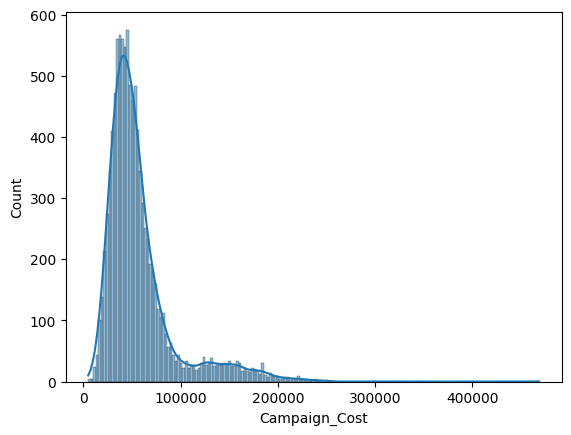

In [14]:
sns.histplot(df1['Campaign_Cost'], kde=True)
plt.show()

#### 6.2 Correlation Heatmap

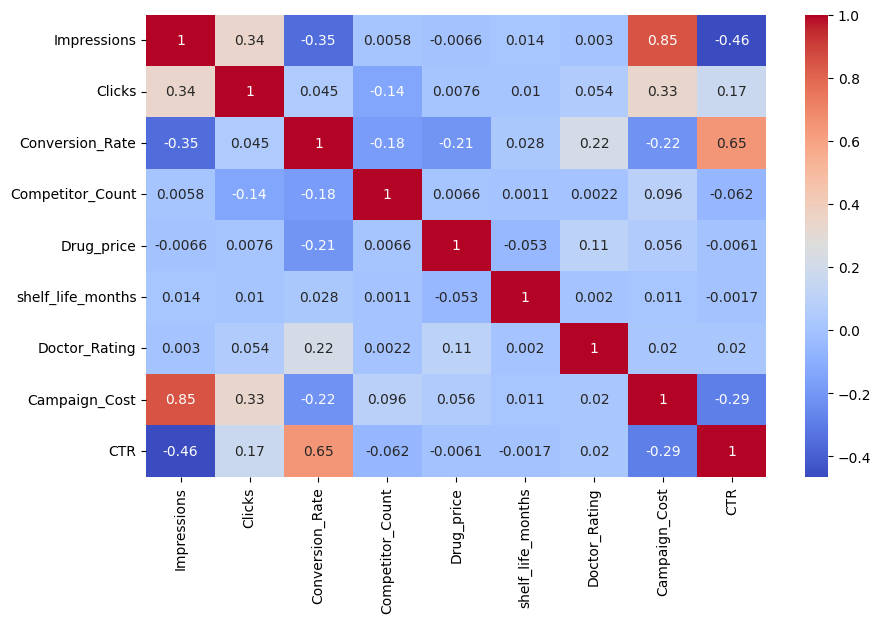

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

#### 6.3 Campaign Type vs Cost

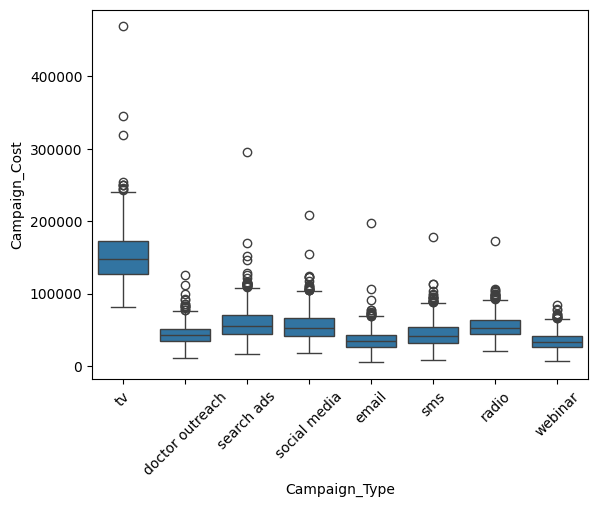

In [17]:
sns.boxplot(x='Campaign_Type', y='Campaign_Cost', data=df1)
plt.xticks(rotation=45)
plt.show()

#### 6.4 Region Analysis

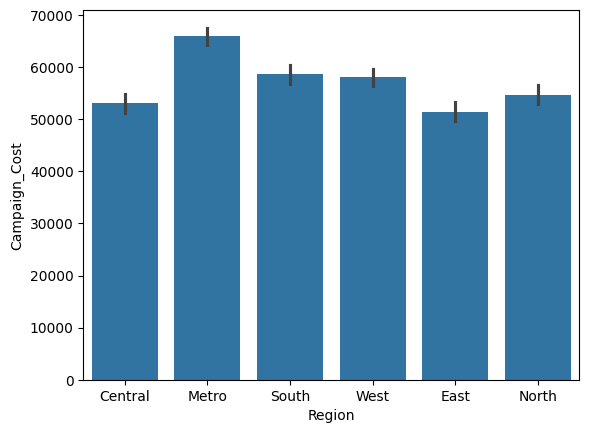

In [18]:
sns.barplot(x='Region', y='Campaign_Cost', data=df1)
plt.show()

#### 7. Encoding Categorical Variables

In [19]:
df1= pd.get_dummies(df1, drop_first=True)
df1

,Impressions,Clicks,Conversion_Rate,Competitor_Count,Drug_price,shelf_life_months,Doctor_Rating,Campaign_Cost,CTR,Campaign_Type_email,...,is_prescription_required_Yes,therapeutic_class_Heart Care,therapeutic_class_Infection,therapeutic_class_Lung Care,therapeutic_class_Neuro Care,therapeutic_class_Pain Relief,therapeutic_class_Skin Care,therapeutic_class_Supplement,storage_condition_Cool,storage_condition_Room Temp
0,355796,5255,0.0020,5,193,24,4.5,150363,0.014770,False,...,True,False,False,False,False,False,False,False,True,False
1,5612,656,0.0621,9,58,24,4.8,25821,0.116892,False,...,True,False,False,False,False,False,False,True,True,False
2,55397,2500,0.0173,6,172,36,4.6,40059,0.045129,False,...,True,False,False,False,False,False,False,False,True,False
3,15666,1412,0.0340,12,116,36,4.4,36156,0.090131,False,...,True,False,True,False,False,False,False,False,False,True
4,139176,4989,0.0020,8,187,24,3.7,75788,0.035847,False,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,23968,4741,0.0396,11,203,18,4.5,72866,0.197805,False,...,True,False,False,False,False,False,False,False,False,True
9996,37073,531,0.0061,8,95,24,4.9,53399,0.014323,False,...,True,False,True,False,False,False,False,False,False,True
9997,122340,7175,0.0092,9,205,36,3.6,103848,0.058648,False,...,True,False,False,False,False,False,True,False,False,True
9998,32329,2488,0.0258,3,86,12,4.5,40584,0.076959,False,...,True,False,False,False,False,False,True,False,False,True


#### 8. Define Features & Target

In [20]:
X = df1.drop('Campaign_Cost', axis=1)
y = df1['Campaign_Cost']

#### 9. Train-Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### 10. Feature Scaling (Important for some models)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 11. Model Building

#### 11.1 Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### 11.2 Random Forest (Better Model)

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### 12. Predictions

In [25]:
y_pred = rf.predict(X_test)
y_pred

array([ 42051.38, 126386.74,  39782.52, ...,  48203.19,  80007.16,
        50620.14], shape=(2000,))

### 13. Model Evaluation

In [30]:
# Predictions on training data
y_train_pred = model.predict(X_train)

# Training metrics
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

# Adjusted R2 for training
n_train = X_train.shape[0]
k_train = X_train.shape[1]

adj_r2_train = 1 - (1 - r2_train) * (n_train - 1) / (n_train - k_train - 1)

print("Training MAE:", mae_train)
print("Training RMSE:", rmse_train)
print("Training R2:", r2_train)
print("Training Adjusted R2:", adj_r2_train)

Training MAE: 8443.51778909729
Training RMSE: 13037.055958443601
Training R2: 0.8740992410755231
Training Adjusted R2: 0.8734028698130872


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Adjusted R2
n = X_test.shape[0]   # number of samples
k = X_test.shape[1]   # number of features

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("Adjusted R2:", adj_r2)

MAE: 8588.491645
RMSE: 12460.228726948475
R2 Score: 0.8815945139554471
Adjusted R2: 0.8789296334511195


### 14. Feature Importance (Important for Project)

In [28]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

             Feature  Importance
13  Campaign_Type_tv    0.681141
0        Impressions    0.132241
1             Clicks    0.039973
16    Channel_Online    0.022799
4         Drug_price    0.019999
3   Competitor_Count    0.012637
18      Region_Metro    0.011393
7                CTR    0.010508
6      Doctor_Rating    0.008244
2    Conversion_Rate    0.006395


### 15. Model Improvement (Optional)

In [29]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestRegressor(), params, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}
